In [25]:
# STEP 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import warnings

# For data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# For balancing
from imblearn.over_sampling import SMOTE

# For model selection and evaluation
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, make_scorer

# Models (SVC for classification)
from sklearn.svm import SVC

# For saving models
import pickle

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")

All libraries imported successfully!


In [26]:
# Load data
data = pd.read_csv("processed_feature_selected.csv")
print("Original data shape:", data.shape)
print("Original columns:", data.columns.tolist())
print(data.head())

# Create binary target: is_healthy (from health_score >= 0.5)
data['is_healthy'] = (data['health_score'] >= 0.5).astype(int)
print("\nis_healthy value counts:\n", data['is_healthy'].value_counts(normalize=True) * 100)

# Save with full path to avoid permission issues
csv_path = r"C:\Users\User\Desktop\ML train\files\Is_Healthy.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
try:
    data.to_csv(csv_path, index=False)
    print(f"Data saved to {csv_path}")
except PermissionError:
    print("Permission denied. Close the file if open, or try a different path.")
    # Fallback: Save to temp name
    csv_path = 'Is_Healthy_temp.csv'
    data.to_csv(csv_path, index=False)
    print("Saved to 'Is_Healthy_temp.csv' instead.")

Original data shape: (10619, 11)
Original columns: ['title', 'rating', 'fat', 'calories', 'protein', 'sodium', 'high fiber', 'fat_level_medium', 'fat_level_high', 'fat_level', 'health_score']
                                               title    rating       fat  \
0        Boudin Blanc Terrine with Red Onion Confit   0.666667  0.310811   
1                      Potato and Fennel Soup Hodge   0.333333  0.094595   
2                          Spinach Noodle Casserole   0.000000  0.432432   
3                             Korean Marinated Beef   0.666667  0.135135   
4  Ham Persillade with Mustard Potato Salad and M...  0.333333  0.554054   

   calories   protein    sodium  high fiber  fat_level_medium  fat_level_high  \
0  0.335554  0.264706  0.840047           0                 0               1   
1  0.137386  0.088235  0.096322           0                 0               0   
2  0.455454  0.294118  0.263865           0                 0               1   
3  0.141549  0.102941  0.74

In [27]:
# STEP 2: Load and Prepare the Dataset
print("LOADING PROCESSED DATASET")

data = pd.read_csv(csv_path)
print("\nDataset Shape:", data.shape)

# Select features (only the 4 nutritions + high_fiber)
feature_cols = ['fat', 'calories', 'protein', 'sodium']
X = data[feature_cols].copy()

# Create high_fiber if 'fiber' column exists (binary: 1 if fiber > median, 0 otherwise)
if 'fiber' in data.columns:
    median_fiber = data['fiber'].median()
    high_fiber = (data['fiber'] > median_fiber).astype(int)
    X['high_fiber'] = high_fiber
    print("Created 'high_fiber' from 'fiber' column (median threshold).")
else:
    print("No 'fiber' column; setting 'high_fiber' to 0 (placeholder).")
    X['high_fiber'] = 0

# Target: is_healthy (binary classification)
y = data['is_healthy']

# Drop any non-selected columns (e.g., title, fat_level, health_score)
print("\nSelected features:", X.columns.tolist())

# Force all to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop all-NaN columns
nan_cols = X.columns[X.isnull().all()].tolist()
if nan_cols:
    print(f"Dropping all-NaN columns: {nan_cols}")
    X = X.drop(columns=nan_cols)

# Impute missing
print("\nMissing values per column:\n", X.isnull().sum())
if X.isnull().any().any():
    imputer = SimpleImputer(strategy='mean')
    imputed_array = imputer.fit_transform(X)
    if imputed_array.shape[1] != len(X.columns):
        X = pd.DataFrame(imputed_array, columns=X.columns[:imputed_array.shape[1]])
    else:
        X = pd.DataFrame(imputed_array, columns=X.columns)
    print("Missing values imputed.")

# Split (80/10/10, stratified on binary target)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print("\nSplit Shapes:")
print(f"Training: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

print("\nClass Distribution (Training):")
print(y_train.value_counts(normalize=True) * 100)

# Scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("\nFeatures:", X_train.shape[1])
print("Sample Features:", ', '.join(X_train.columns.tolist()))

print("\nData preparation complete!")

# Balance classes with SMOTE (to make model sensitive to inputs)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE balancing:")
print(y_train_bal.value_counts(normalize=True) * 100)

# Use balanced for training
X_train = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_train = y_train_bal

LOADING PROCESSED DATASET

Dataset Shape: (10619, 12)
No 'fiber' column; setting 'high_fiber' to 0 (placeholder).

Selected features: ['fat', 'calories', 'protein', 'sodium', 'high_fiber']

Missing values per column:
 fat           0
calories      0
protein       0
sodium        0
high_fiber    0
dtype: int64

Split Shapes:
Training: (8495, 5), Val: (1062, 5), Test: (1062, 5)

Class Distribution (Training):
is_healthy
1    55.8093
0    44.1907
Name: proportion, dtype: float64

Features: 5
Sample Features: fat, calories, protein, sodium, high_fiber

Data preparation complete!

After SMOTE balancing:
is_healthy
1    50.0
0    50.0
Name: proportion, dtype: float64


EXPLORATORY DATA ANALYSIS

Feature Statistics:
             count      mean       std       min       25%       50%  \
fat         9482.0  0.069366  1.014927 -1.272666 -0.712260 -0.151853   
calories    9482.0  0.058139  1.011014 -1.646324 -0.708357 -0.142947   
protein     9482.0  0.035846  1.012067 -0.953617 -0.686417 -0.419217   
sodium      9482.0  0.036704  1.016241 -1.012885 -0.768663 -0.290501   
high_fiber  9482.0  0.000000  0.000000  0.000000  0.000000  0.000000   

                 75%       max  
fat         0.595355  3.335119  
calories    0.689827  3.617685  
protein     0.515984  3.588788  
sodium      0.565563  3.390833  
high_fiber  0.000000  0.000000  

Feature Correlations with Target (is_healthy):
fat: -0.6509
calories: -0.5547
protein: -0.3279
sodium: -0.3682
high_fiber: nan


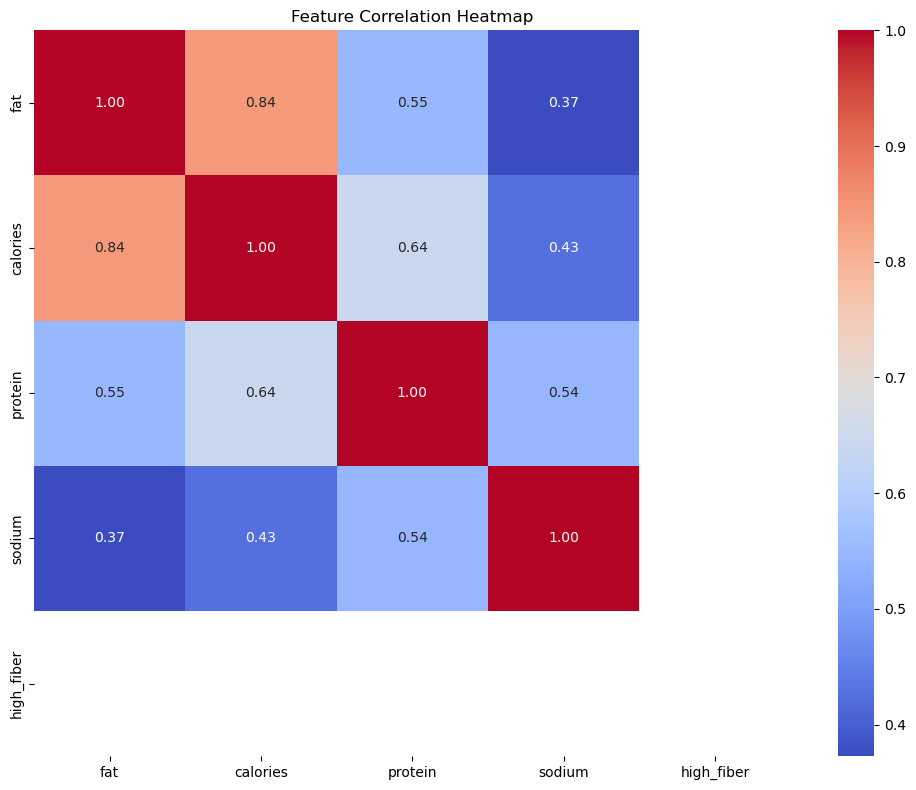

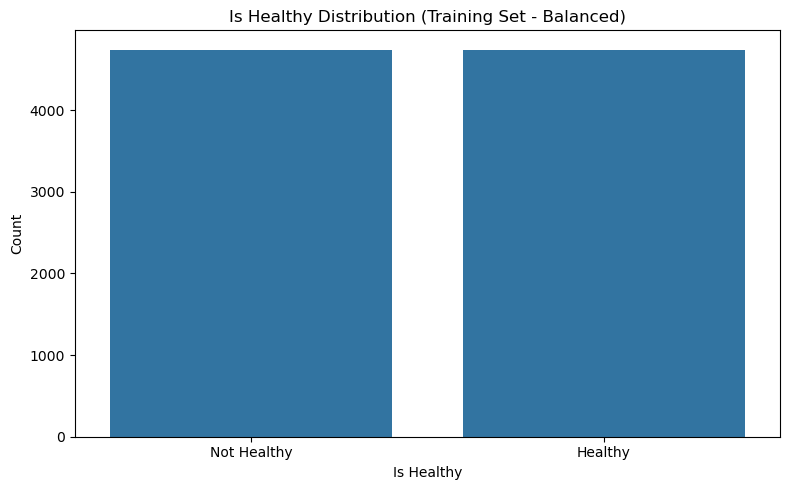


EDA complete!


In [28]:
# STEP 3: Exploratory Data Analysis
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)

print("\nFeature Statistics:")
print(X_train.describe().T)

# Correlation with target (is_healthy)
print("\nFeature Correlations with Target (is_healthy):")
for feat in X_train.columns:
    correlation = X_train[feat].corr(y_train)
    print(f"{feat}: {correlation:.4f}")

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = X_train.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title('Is Healthy Distribution (Training Set - Balanced)')
plt.xlabel('Is Healthy')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Healthy', 'Healthy'])
plt.tight_layout()
plt.show()

print("\nEDA complete!")



STEP 4: BASIC MODEL TRAINING

Basic SVC Performance:
Training Metrics:
  Accuracy: 0.9271
  F1 Score: 0.9296

Validation Metrics:
  Accuracy: 0.9209
  F1 Score: 0.9308

Overfitting Check (Train-Val Gaps):
  Accuracy: 0.0062
  F1 Score: -0.0012
Good: Low gaps indicate generalization.


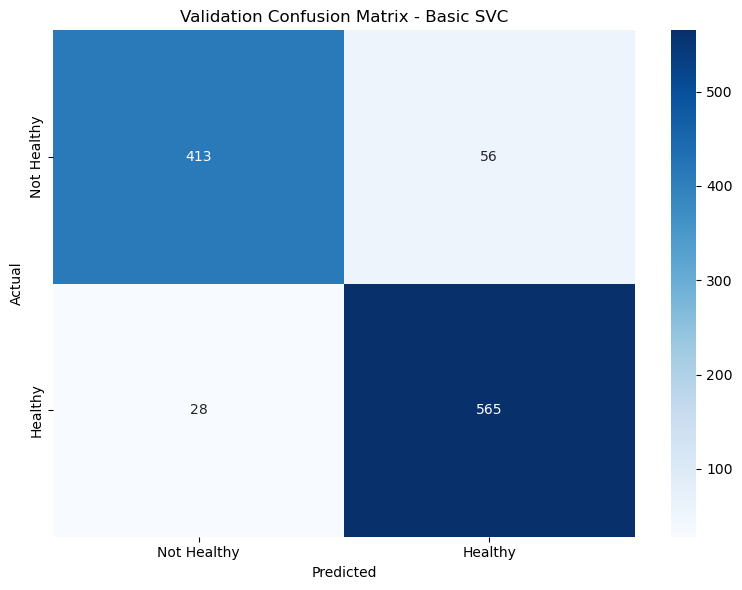


Basic model training and evaluation complete!


In [30]:
# STEP 4: Basic Model Training
print("STEP 4: BASIC MODEL TRAINING")
print("=" * 50)

svc_basic = SVC(random_state=RANDOM_STATE, probability=True)
svc_basic.fit(X_train, y_train)

y_train_pred = svc_basic.predict(X_train)
y_val_pred = svc_basic.predict(X_val)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_f1 = f1_score(y_val, y_val_pred)

train_metrics = {
    'Accuracy': train_acc,
    'F1 Score': train_f1
}

val_metrics = {
    'Accuracy': val_acc,
    'F1 Score': val_f1
}

print("\nBasic SVC Performance:")
print("Training Metrics:")
for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nValidation Metrics:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Overfitting Check: Train-Val Gap
gaps = {metric: train_metrics[metric] - val_metrics[metric] for metric in train_metrics}
print("\nOverfitting Check (Train-Val Gaps):")
for metric, gap in gaps.items():
    print(f"  {metric}: {gap:.4f}")
if max(gaps.values()) > 0.1:
    print("Warning: Potential overfitting (gap >0.1); consider stronger regularization (lower C).")
else:
    print("Good: Low gaps indicate generalization.")

# Confusion Matrix for Validation
plt.figure(figsize=(8, 6))
cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Healthy', 'Healthy'], 
            yticklabels=['Not Healthy', 'Healthy'])
plt.title('Validation Confusion Matrix - Basic SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nBasic model training and evaluation complete!")

STEP 5: ADVANCED HYPERPARAMETER TUNING FOR SVC MODEL
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best Hyperparameters:
{'C': 100, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

Tuned Model Performance:
Training Metrics:
  Accuracy: 0.9329
  F1 Score: 0.9348

Validation Metrics:
  Accuracy: 0.9247
  F1 Score: 0.9336

Overfitting Check for Tuned Model (Train-Val Gaps):
  Accuracy: 0.0083
  F1 Score: 0.0013
Good: Low gaps in tuned model indicate strong generalization.


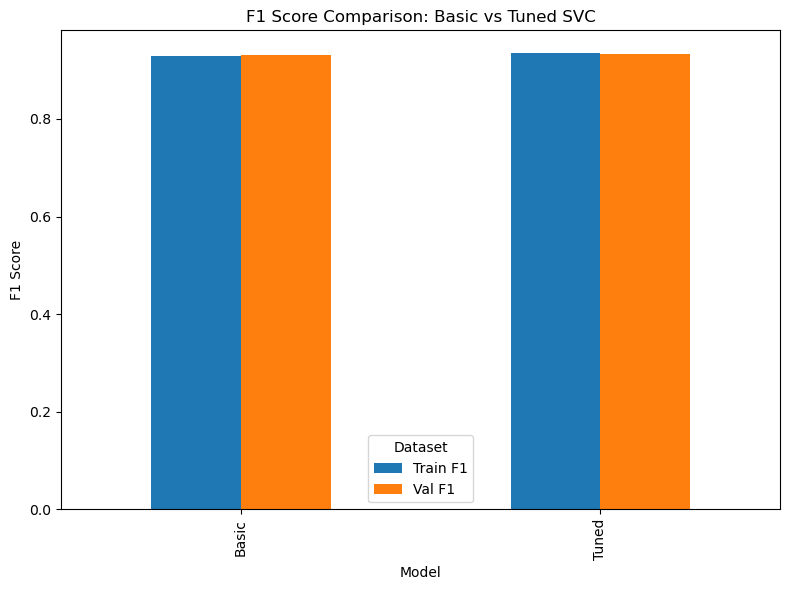

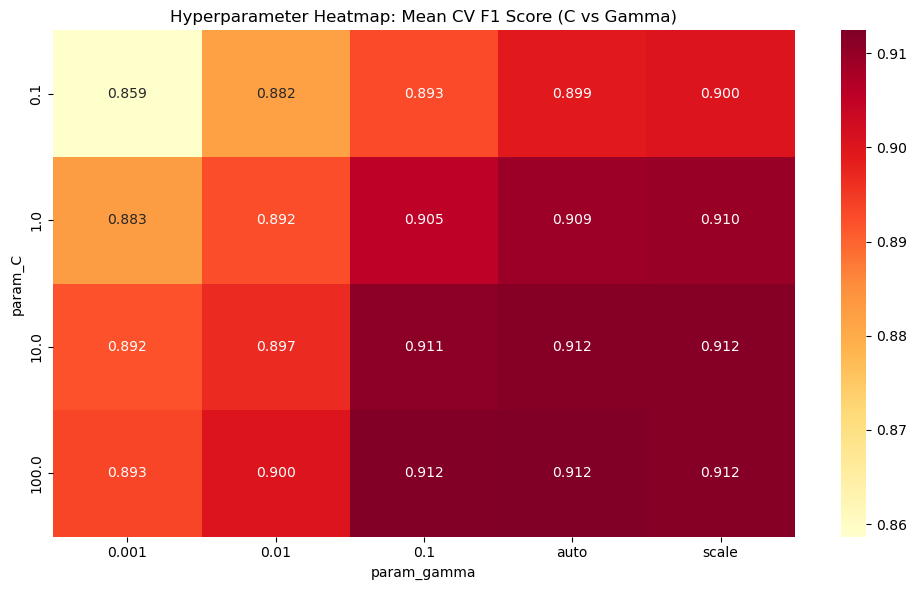


Advanced hyperparameter tuning complete!


In [31]:
# STEP 5: Advanced Hyperparameter Tuning for SVC Model
print("STEP 5: ADVANCED HYPERPARAMETER TUNING FOR SVC MODEL")
print("=" * 50)

# Conservative hyperparameter grid to ensure generalization
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
    'class_weight': ['balanced', None]
}

# GridSearchCV with 5 folds for efficiency
svc_model = SVC(random_state=RANDOM_STATE, probability=True)
grid_search = GridSearchCV(estimator=svc_model, param_grid=param_grid, 
                          cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_svc_model = grid_search.best_estimator_
print("\nBest Hyperparameters:")
print(grid_search.best_params_)

# Evaluate tuned model
y_train_pred_tuned = best_svc_model.predict(X_train)
y_val_pred_tuned = best_svc_model.predict(X_val)

train_acc_tuned = accuracy_score(y_train, y_train_pred_tuned)
val_acc_tuned = accuracy_score(y_val, y_val_pred_tuned)
train_f1_tuned = f1_score(y_train, y_train_pred_tuned)
val_f1_tuned = f1_score(y_val, y_val_pred_tuned)

train_metrics_tuned = {
    'Accuracy': train_acc_tuned,
    'F1 Score': train_f1_tuned
}

val_metrics_tuned = {
    'Accuracy': val_acc_tuned,
    'F1 Score': val_f1_tuned
}

print("\nTuned Model Performance:")
print("Training Metrics:")
for metric, value in train_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")

print("\nValidation Metrics:")
for metric, value in val_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")

# Overfitting Check: Train-Val Gap for Tuned Model
gaps_tuned = {metric: train_metrics_tuned[metric] - val_metrics_tuned[metric] 
              for metric in train_metrics_tuned}
print("\nOverfitting Check for Tuned Model (Train-Val Gaps):")
for metric, gap in gaps_tuned.items():
    print(f"  {metric}: {gap:.4f}")
if max(gaps_tuned.values()) > 0.1:
    print("Warning: Potential overfitting in tuned model (gap >0.1); review hyperparameters (lower C).")
else:
    print("Good: Low gaps in tuned model indicate strong generalization.")

# Visualization: Comparison of Basic vs Tuned Model (F1 Scores)
comparison_data = {
    'Model': ['Basic', 'Tuned'],
    'Train F1': [train_metrics['F1 Score'], train_metrics_tuned['F1 Score']],
    'Val F1': [val_metrics['F1 Score'], val_metrics_tuned['F1 Score']]
}
comp_df = pd.DataFrame(comparison_data)
comp_df.set_index('Model').plot(kind='bar', figsize=(8, 6))
plt.title('F1 Score Comparison: Basic vs Tuned SVC')
plt.ylabel('F1 Score')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Hyperparameter Impact Visualization (C vs gamma heatmap)
results_df = pd.DataFrame(grid_search.cv_results_)
if 'param_C' in results_df.columns and 'param_gamma' in results_df.columns:
    pivot_df = results_df.pivot_table(values='mean_test_score', 
                                      index='param_C', 
                                      columns='param_gamma', 
                                      aggfunc='mean')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd')
    plt.title('Hyperparameter Heatmap: Mean CV F1 Score (C vs Gamma)')
    plt.tight_layout()
    plt.show()

print("\nAdvanced hyperparameter tuning complete!")

STEP 6: CROSS-VALIDATION ANALYSIS

Cross-Validation F1 Scores:
[0.93711968 0.92276215 0.93814433 0.93203883 0.92615385]
Mean CV F1: 0.9312 (+/- 0.0120)

Cross-Validation Accuracy Scores:
[0.93463363 0.92040063 0.93670886 0.92985232 0.92405063]
Mean CV Accuracy: 0.9291 (+/- 0.0123)

Cross-Validation Precision Scores:
[0.90322581 0.89572989 0.91733871 0.90386521 0.9011976 ]
Mean CV Precision: 0.9043 (+/- 0.0143)

Cross-Validation Recall Scores:
[0.97365648 0.95147679 0.95991561 0.96202532 0.95253165]
Mean CV Recall: 0.9599 (+/- 0.0160)

CV Overfitting Check: F1 Std = 0.0060 (low std <0.05 suggests good generalization; high indicates overfitting to specific folds).


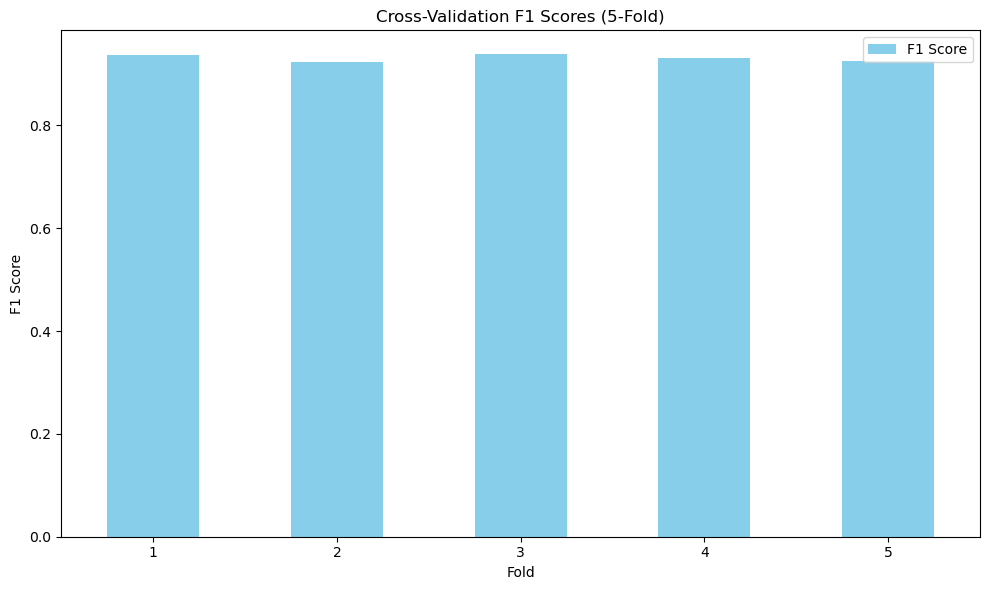

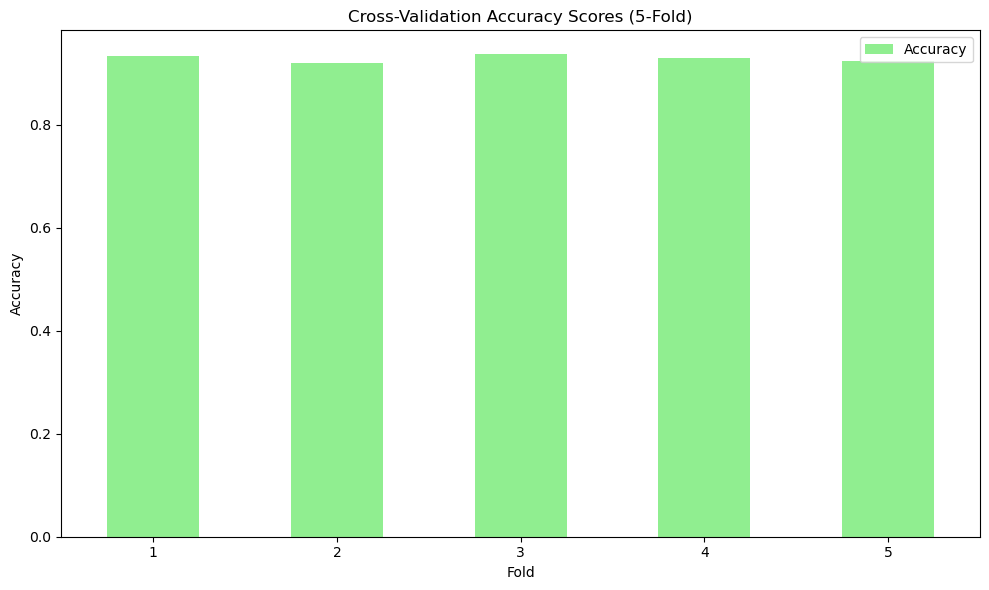


CV Summary Table:
      Metric    Mean     Std
0   F1 Score  0.9312  0.0060
1   Accuracy  0.9291  0.0062
2  Precision  0.9043  0.0071
3     Recall  0.9599  0.0080


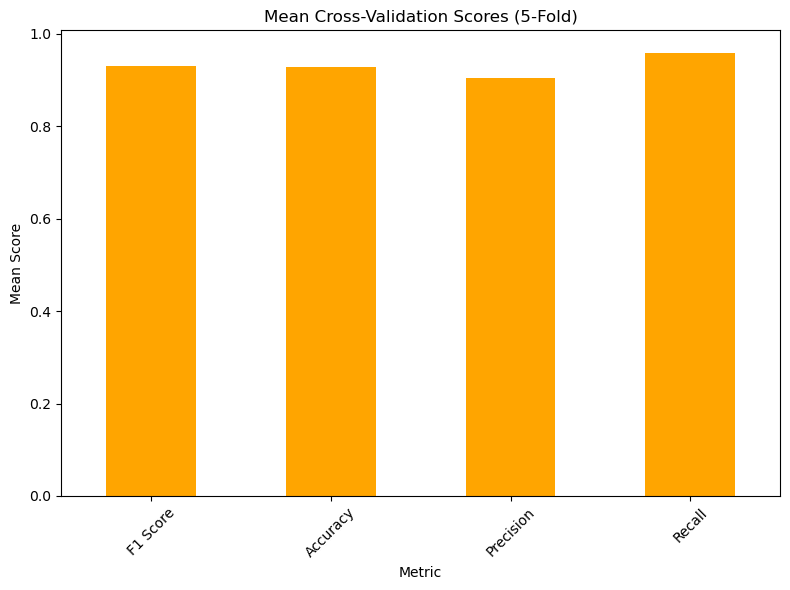

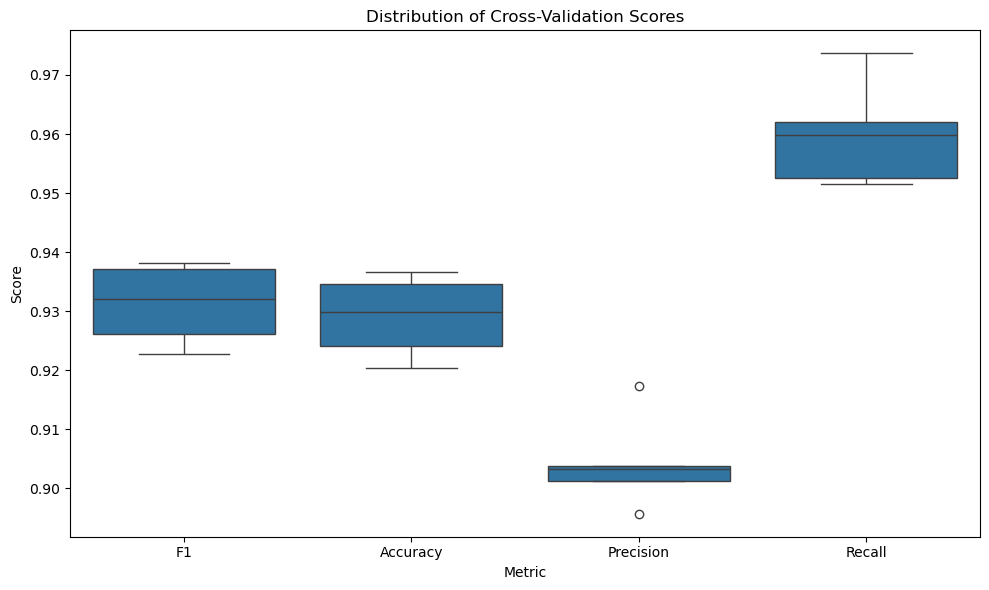


Cross-validation analysis complete!


In [32]:
# STEP 6: Cross-Validation Analysis
print("STEP 6: CROSS-VALIDATION ANALYSIS")
print("=" * 50)

# Cross-validation setup (5 folds for SVC efficiency)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Multiple metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(best_svc_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# Extract scores
cv_f1_scores = cv_results['test_f1']
cv_acc_scores = cv_results['test_accuracy']
cv_precision_scores = cv_results['test_precision']
cv_recall_scores = cv_results['test_recall']

print("\nCross-Validation F1 Scores:")
print(cv_f1_scores)
print(f"Mean CV F1: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std() * 2:.4f})")

print("\nCross-Validation Accuracy Scores:")
print(cv_acc_scores)
print(f"Mean CV Accuracy: {cv_acc_scores.mean():.4f} (+/- {cv_acc_scores.std() * 2:.4f})")

print("\nCross-Validation Precision Scores:")
print(cv_precision_scores)
print(f"Mean CV Precision: {cv_precision_scores.mean():.4f} (+/- {cv_precision_scores.std() * 2:.4f})")

print("\nCross-Validation Recall Scores:")
print(cv_recall_scores)
print(f"Mean CV Recall: {cv_recall_scores.mean():.4f} (+/- {cv_recall_scores.std() * 2:.4f})")

# Overfitting Check via CV Variance (low std indicates stability, no overfitting)
cv_std_f1 = cv_f1_scores.std()
print(f"\nCV Overfitting Check: F1 Std = {cv_std_f1:.4f} (low std <0.05 suggests good generalization; high indicates overfitting to specific folds).")

# Visualization: Bar Chart for CV F1 Scores
cv_f1_df = pd.DataFrame({'Fold': range(1, 6), 'F1 Score': cv_f1_scores})
cv_f1_df.plot(x='Fold', kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Cross-Validation F1 Scores (5-Fold)')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualization: Bar Chart for CV Accuracy Scores
cv_acc_df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': cv_acc_scores})
cv_acc_df.plot(x='Fold', kind='bar', figsize=(10, 6), color='lightgreen')
plt.title('Cross-Validation Accuracy Scores (5-Fold)')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary Table for CV Metrics
cv_summary = pd.DataFrame({
    'Metric': ['F1 Score', 'Accuracy', 'Precision', 'Recall'],
    'Mean': [cv_f1_scores.mean(), cv_acc_scores.mean(), cv_precision_scores.mean(), cv_recall_scores.mean()],
    'Std': [cv_f1_scores.std(), cv_acc_scores.std(), cv_precision_scores.std(), cv_recall_scores.std()]
})
print("\nCV Summary Table:")
print(cv_summary.round(4))

# Bar Chart for Mean CV Scores
cv_summary.set_index('Metric')['Mean'].plot(kind='bar', figsize=(8, 6), color='orange')
plt.title('Mean Cross-Validation Scores (5-Fold)')
plt.ylabel('Mean Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Box Plot for CV Score Distribution
cv_scores_long = pd.DataFrame({
    'F1': cv_f1_scores,
    'Accuracy': cv_acc_scores,
    'Precision': cv_precision_scores,
    'Recall': cv_recall_scores
}).melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_scores_long, x='Metric', y='Score')
plt.title('Distribution of Cross-Validation Scores')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

print("\nCross-validation analysis complete!")

STEP 7: MODEL COMPARISON AND FINAL EVALUATION

Basic Model Test Performance:
  Accuracy: 0.9247
  Precision: 0.9078
  Recall: 0.9629
  F1 Score: 0.9345
  AUC: 0.9374

Tuned Model Test Performance:
  Accuracy: 0.9266
  Precision: 0.9160
  Recall: 0.9562
  F1 Score: 0.9356
  AUC: 0.9523

Model Comparison (Test Set):
   Model  Accuracy  F1 Score     AUC
0  Basic    0.9247    0.9345  0.9374
1  Tuned    0.9266    0.9356  0.9523


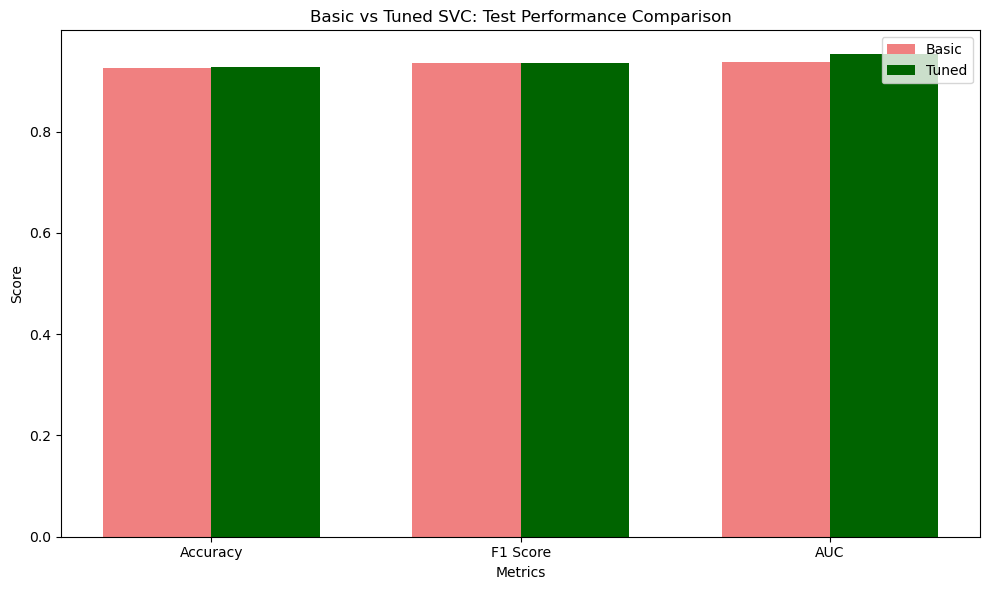

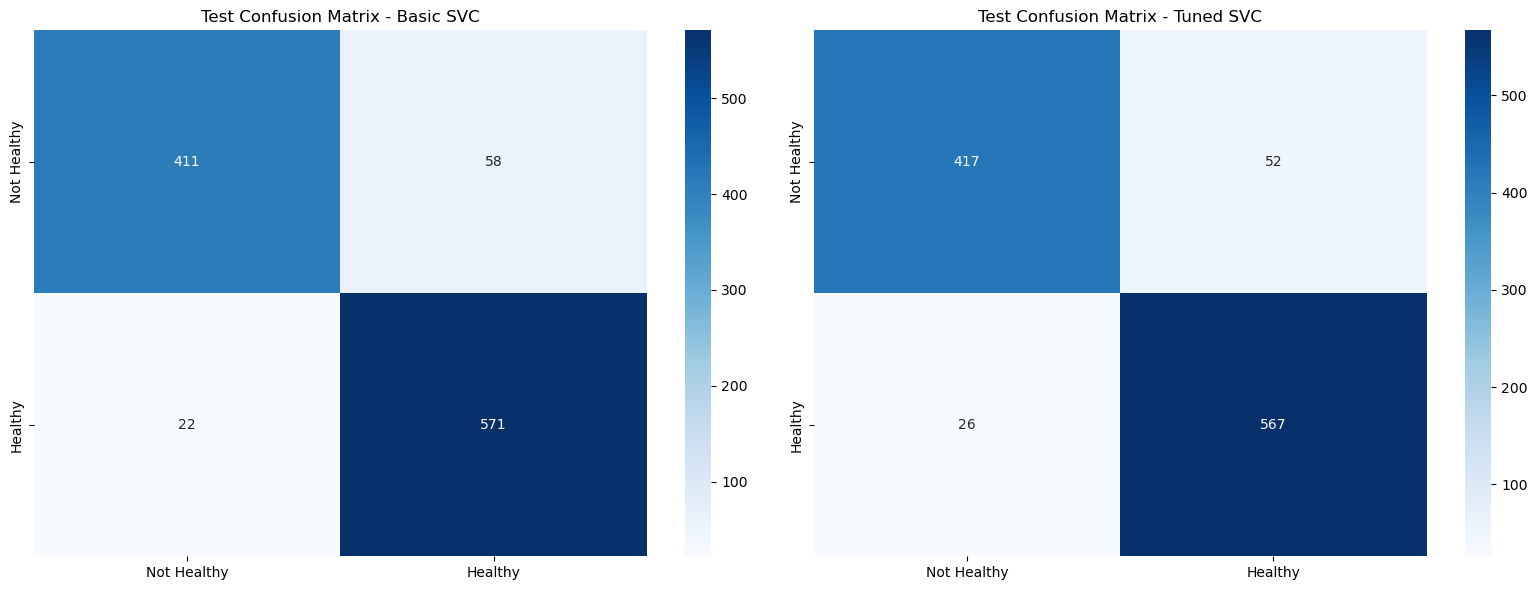

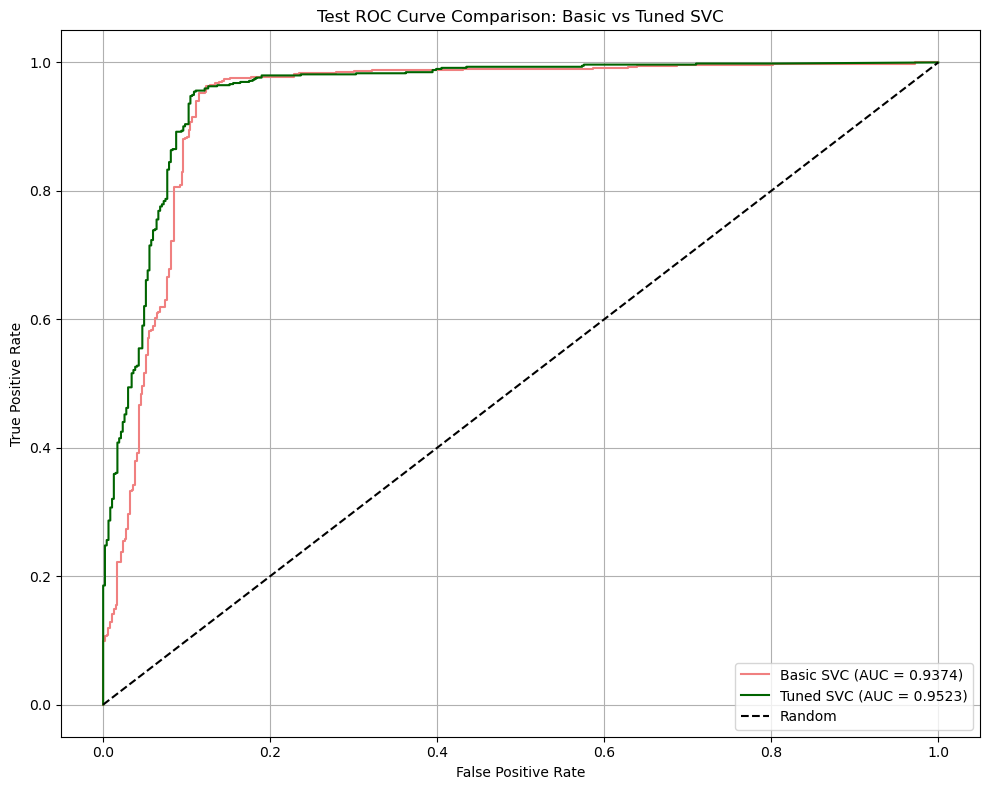


Tuned model saved to C:\Users\User\Desktop\ML train\files\tuned_svc_model.pkl

Model comparison and final evaluation complete!


In [33]:
# STEP 7: Model Comparison and Final Evaluation
print("STEP 7: MODEL COMPARISON AND FINAL EVALUATION")
print("=" * 50)

# Evaluate basic model on test set
y_test_pred_basic = svc_basic.predict(X_test)
y_test_proba_basic = svc_basic.predict_proba(X_test)[:, 1]

test_metrics_basic = {
    'Accuracy': accuracy_score(y_test, y_test_pred_basic),
    'Precision': precision_score(y_test, y_test_pred_basic),
    'Recall': recall_score(y_test, y_test_pred_basic),
    'F1 Score': f1_score(y_test, y_test_pred_basic),
    'AUC': roc_auc_score(y_test, y_test_proba_basic)
}

# Evaluate tuned model on test set
y_test_pred_tuned = best_svc_model.predict(X_test)
y_test_proba_tuned = best_svc_model.predict_proba(X_test)[:, 1]

test_metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_test_pred_tuned),
    'Precision': precision_score(y_test, y_test_pred_tuned),
    'Recall': recall_score(y_test, y_test_pred_tuned),
    'F1 Score': f1_score(y_test, y_test_pred_tuned),
    'AUC': roc_auc_score(y_test, y_test_proba_tuned)
}

# Print metrics
print("\nBasic Model Test Performance:")
for metric, value in test_metrics_basic.items():
    print(f"  {metric}: {value:.4f}")

print("\nTuned Model Test Performance:")
for metric, value in test_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")

# Comparison DataFrame
comparison_data = {
    'Model': ['Basic', 'Tuned'],
    'Accuracy': [test_metrics_basic['Accuracy'], test_metrics_tuned['Accuracy']],
    'F1 Score': [test_metrics_basic['F1 Score'], test_metrics_tuned['F1 Score']],
    'AUC': [test_metrics_basic['AUC'], test_metrics_tuned['AUC']]
}
comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison (Test Set):")
print(comparison_df.round(4))



# Visualization: Bar Chart for Metrics Comparison (Test Set)
plt.figure(figsize=(10, 6))
metrics_to_plot = ['Accuracy', 'F1 Score', 'AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

plt.bar(x - width/2, [test_metrics_basic[m] for m in metrics_to_plot], width, label='Basic', color='lightcoral')
plt.bar(x + width/2, [test_metrics_tuned[m] for m in metrics_to_plot], width, label='Tuned', color='darkgreen')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Basic vs Tuned SVC: Test Performance Comparison')
plt.xticks(x, metrics_to_plot)
plt.legend()
plt.tight_layout()
plt.show()

# Side-by-Side Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Basic CM
cm_basic = confusion_matrix(y_test, y_test_pred_basic)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Healthy', 'Healthy'], 
            yticklabels=['Not Healthy', 'Healthy'], ax=ax1)
ax1.set_title('Test Confusion Matrix - Basic SVC')

# Tuned CM
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Healthy', 'Healthy'], 
            yticklabels=['Not Healthy', 'Healthy'], ax=ax2)
ax2.set_title('Test Confusion Matrix - Tuned SVC')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
fpr_basic, tpr_basic, _ = roc_curve(y_test, y_test_proba_basic)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_test_proba_tuned)

plt.figure(figsize=(10, 8))
plt.plot(fpr_basic, tpr_basic, label=f'Basic SVC (AUC = {test_metrics_basic["AUC"]:.4f})', color='lightcoral')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned SVC (AUC = {test_metrics_tuned["AUC"]:.4f})', color='darkgreen')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve Comparison: Basic vs Tuned SVC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save tuned model and scaler
models_dir = r"C:\Users\User\Desktop\ML train\files"
os.makedirs(models_dir, exist_ok=True)
with open(os.path.join(models_dir, "tuned_svc_model.pkl"), "wb") as f:
    pickle.dump(best_svc_model, f)
with open(os.path.join(models_dir, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print(f"\nTuned model saved to {os.path.join(models_dir, 'tuned_svc_model.pkl')}")

print("\nModel comparison and final evaluation complete!")